In [2]:
import mysql.connector
from tabulate import tabulate
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
conn = mysql.connector.connect(
    host = "localhost",
    user = "root",
    password = "B@1Guy202",
    database = "retail_db"
)

cursor = conn.cursor()

In [7]:
# Groups the order details by customer segment and provides counts, total revenue, revenue per person, and profit margin per person
cursor.execute(
    """
    SELECT customersegment, COUNT(customersegment),
        CONCAT("$", FORMAT(SUM(unitprice * quantity * (1-discountrate)), 2)),
        CONCAT("$", FORMAT(SUM(unitprice * quantity * (1-discountrate)) / COUNT(customersegment), 2)) AS revenue_per_person,
        CONCAT(
            ROUND(
                (
                    SUM((unitprice - unitcost) * quantity * (1 - discountrate)) 
                    / COUNT(customersegment)
                ) /
                (
                    SUM(unitprice * quantity * (1 - discountrate)) 
                    / COUNT(customersegment)
                ) * 100,
            2),
            "%"
        ) AS profit_margin_per_person
    FROM customers
    JOIN orders ON customers.customerid = orders.customerid
    JOIN order_details ON orders.orderid = order_details.orderid
    GROUP BY customersegment
    """
)

In [8]:
output = cursor.fetchall()
print(tabulate(output, headers = ["customersegment", "count", "total_revenue", "revenue/person", "profit_margin/person"], tablefmt="github"))

| customersegment   |   count | total_revenue   | revenue/person   | profit_margin/person   |
|-------------------|---------|-----------------|------------------|------------------------|
| Standard          |   13799 | $291,110.09     | $21.10           | 30.47%                 |
| Premium           |   11163 | $297,125.61     | $26.62           | 30.59%                 |
| VIP               |    5309 | $173,715.43     | $32.72           | 30.42%                 |


In [ ]:
# As depicted in the table above, generally more customers fall into the "Standard" and "Premium" segment.
# Going from Standard to VIP, the amount spent per customer increases. That said, the profit margin per customer stays relatively
# across customer segments.

In [9]:
# Lists the products sold, their total revenue, total profit, profit margin, profit margin percentile relative to other products, 
# and labels whether the percentile is low or high
cursor.execute(
    """
    SELECT productname,
        CONCAT("$", FORMAT(total_revenue, 2)),
        CONCAT("$", FORMAT(total_profit, 2)),
        CONCAT(ROUND(profit_margin, 0), "%"),
        CONCAT(ROUND(PERCENT_RANK() OVER (ORDER BY profit_margin) * 100, 0), "th") AS profit_percentile,

        CASE 
            WHEN PERCENT_RANK() OVER (ORDER BY profit_margin) * 100 < 10 THEN 'Very Low      (*)'
            WHEN PERCENT_RANK() OVER (ORDER BY profit_margin) * 100 < 25 THEN 'Low           (* *)'
            WHEN PERCENT_RANK() OVER (ORDER BY profit_margin) * 100 < 50 THEN 'Below Average (* * *)'
            WHEN PERCENT_RANK() OVER (ORDER BY profit_margin) * 100 < 75 THEN 'Above Average (* * * *)'
            WHEN PERCENT_RANK() OVER (ORDER BY profit_margin) * 100 < 90 THEN 'High          (* * * * *)'
            ELSE 'Very High     (* * * * * *)'
        END AS percentile_label
    FROM(
            SELECT productname,
            SUM(unitprice * quantity * (1-discountrate)) AS total_revenue,
            SUM((unitprice - unitcost) * quantity * (1-discountrate)) AS total_profit,
            (SUM((unitprice - unitcost) * quantity * (1-discountrate)) / SUM(unitprice * quantity * (1-discountrate)))*100 AS profit_margin
        FROM order_details
        JOIN products ON order_details.productid = products.productid
        GROUP BY products.productid
    ) AS totals_by_product
    ORDER BY total_revenue DESC
    """
)

In [10]:
output = cursor.fetchall()
print(tabulate(output, headers = ["product_name", "total_revenue", "total_profit", "profit_margin", "profit_percentile", "percentile_label"], tablefmt="github"))

| product_name                 | total_revenue   | total_profit   | profit_margin   | profit_percentile   | percentile_label            |
|------------------------------|-----------------|----------------|-----------------|---------------------|-----------------------------|
| ABC's Ground Beef            | $38,795.06      | $13,876.50     | 36%             | 77th                | High          (* * * * *)   |
| XYZ's Chicken Breast         | $36,621.72      | $10,261.35     | 28%             | 37th                | Below Average (* * *)       |
| XYZ's Atlantic Salmon        | $34,391.07      | $8,890.54      | 26%             | 28th                | Below Average (* * *)       |
| ABC's Tuna Steak             | $27,209.95      | $9,302.45      | 34%             | 67th                | Above Average (* * * *)     |
| KLM's Duck Breast            | $26,192.52      | $7,732.19      | 30%             | 44th                | Below Average (* * *)       |
| ABC's Beef Ribeye            | $

In [ ]:
# The above table lists every product sold, along with their gross total revenue, profit, and profit margin. It then details how
# profit stacks up relative to each product, assigning a percentile from 0th to 100th. A helper column depicts what percentile is
# low vs. high.

In [19]:
# Charts the profit margin percentile and total revenue that falls under the buckets
# Converts sql output to DataFrame
df = pd.DataFrame(
    output,
    columns = ["product_name", "total_revenue", "total_profit", "profit_margin", "profit_percentile", "percentile_label"]
)

# Converts total revenue to float
df["total_revenue"] = (
    df["total_revenue"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

# Converts profit_margin to float
df["profit_margin"] = (
    df["profit_margin"]
    .str.replace("%", "", regex=False)
    .astype(float)
)

In [27]:
# Creates profit margin bins into equal bins of 5. It then groups by the bins of 5 and gets the total revenue for each bin.
df["profit_bin"] = pd.cut(df["profit_margin"], bins=5)
bin_revenue = df.groupby("profit_bin")["total_revenue"].sum()

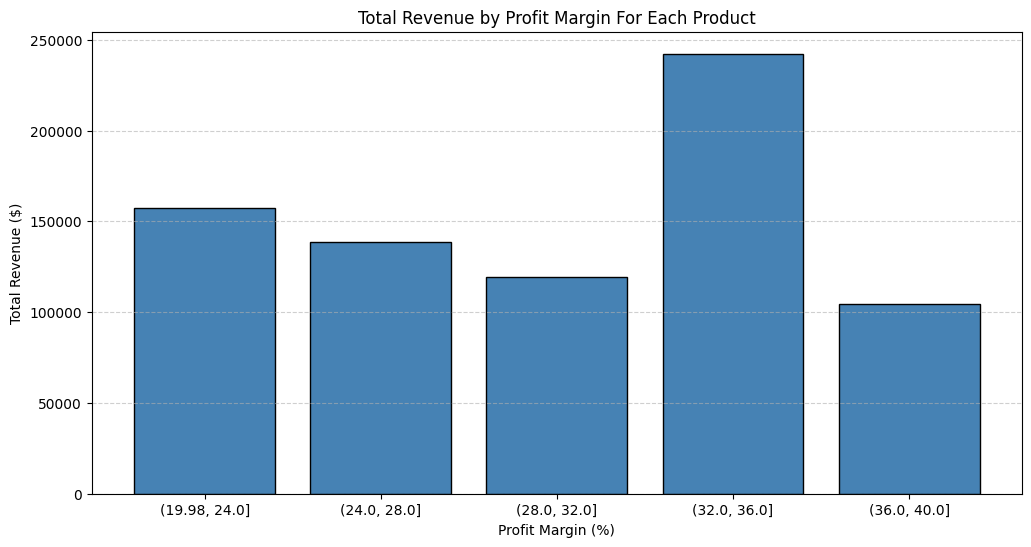

In [28]:
plt.figure(figsize=(12, 6))
plt.bar(
    bin_revenue.index.astype(str),
    bin_revenue.values,
    color="steelblue",
    edgecolor="black"
)

plt.xlabel("Profit Margin (%)")
plt.ylabel("Total Revenue ($)")
plt.title("Total Revenue by Profit Margin For Each Product")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

In [55]:
cursor.execute(
    """
    WITH product_table AS (
        SELECT productname,
            total_revenue,
            total_profit,
            profit_margin,
            CONCAT(ROUND(PERCENT_RANK() OVER (ORDER BY profit_margin) * 100, 0), "th") AS profit_percentile,
    
            CASE 
                WHEN PERCENT_RANK() OVER (ORDER BY profit_margin) * 100 < 10 THEN 'Very Low      (0th - 9th)   (*)'
                WHEN PERCENT_RANK() OVER (ORDER BY profit_margin) * 100 < 25 THEN 'Low           (10th - 24th) (* *)'
                WHEN PERCENT_RANK() OVER (ORDER BY profit_margin) * 100 < 50 THEN 'Below Average (25th - 49th) (* * *)'
                WHEN PERCENT_RANK() OVER (ORDER BY profit_margin) * 100 < 75 THEN 'Above Average (50th - 74th) (* * * *)'
                WHEN PERCENT_RANK() OVER (ORDER BY profit_margin) * 100 < 90 THEN 'High          (75th - 89th) (* * * * *)'
                ELSE 'Very High     (90th - 100th)(* * * * * *)'
            END AS percentile_label
        FROM(
                SELECT productname,
                SUM(unitprice * quantity * (1-discountrate)) AS total_revenue,
                SUM((unitprice - unitcost) * quantity * (1-discountrate)) AS total_profit,
                (SUM((unitprice - unitcost) * quantity * (1-discountrate)) / SUM(unitprice * quantity * (1-discountrate)))*100 AS profit_margin
            FROM order_details
            JOIN products ON order_details.productid = products.productid
            GROUP BY products.productid
        ) AS totals_by_product
    )

    SELECT 
        percentile_label,
        CONCAT("$", FORMAT(SUM(total_revenue), 2)) AS total_revenue,
        CONCAT(ROUND(
            SUM(total_revenue) / SUM(SUM(total_revenue)) OVER () * 100, 
            0),
        "%") AS revenue_share
    FROM product_table
    GROUP BY percentile_label
    ORDER BY CHAR_LENGTH(percentile_label) DESC
    """
)

In [56]:
output = cursor.fetchall()
print(tabulate(output, headers = ["percentile_label", "revenue_by_label", "percent_of_total"], tablefmt="github"))

| percentile_label                          | revenue_by_label   | percent_of_total   |
|-------------------------------------------|--------------------|--------------------|
| Very High     (90th - 100th)(* * * * * *) | $50,984.59         | 7%                 |
| High          (75th - 89th) (* * * * *)   | $153,682.42        | 20%                |
| Above Average (50th - 74th) (* * * *)     | $182,276.01        | 24%                |
| Below Average (25th - 49th) (* * *)       | $200,585.11        | 26%                |
| Low           (10th - 24th) (* *)         | $99,586.44         | 13%                |
| Very Low      (0th - 9th)   (*)           | $74,836.56         | 10%                |
